# Step 1: Explore the data before modeling

**The question the regression will answer:** is SFO's high late-arrival rate really about SFO,
or is it explained by *when* its flights arrive, *which carriers* fly there, *what kind* of
flights they are, or *the weather*?

This notebook does not fit a model yet. It checks whether the data can support one:

1. How much data do we have, and is it spread evenly across days?
2. How different are the airports' late rates, and does the gap survive simple checks?
3. Is there enough weather variation to use, and which weather columns can we trust?
4. When are flights scheduled to arrive, and does that explain SFO?
5. Which carriers have enough flights to estimate on their own?
6. Which flights drop out when we require a weather match?
7. What are the limits of the delay measurement itself?

**"Late"** means the flight arrived 15 or more minutes after its scheduled time. The source's
"actual" arrival is the runway (wheels-on) time, while the schedule is a gate time, so this is
landing 15+ minutes after the scheduled gate arrival: more lenient than the government's gate-based
rule, and taxi-in time is not included.

**Re-running:** the data loads live from Snowflake, but stops at the 1 October pull. Pulls from
3 October onward are held out for the confirmatory test in `02_regression.ipynb`, so exploring them
here would spoil it. If Snowflake can't be reached it falls back to the CSV backup and says so.

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

from flights_data import load_flights, prepare, pull_dates

pd.set_option("display.precision", 3)

# Chart style: one series color, quiet axes and gridlines so the data stands out.
BAR_COLOR = "#2a78d6"
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e6e3",
    "axes.edgecolor": "#8a8985",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.titlesize": 11,
})

Loading and preparation live in `flights_data.py`, shared with the other notebooks.
`prepare()` removes rows whose schedule belongs to a different flight, then adds the columns used
below: scheduled arrival hour and time of day, carrier with livery names merged, a cargo flag, and
which API pull captured each flight. Read that file for the reasoning behind each one.

In [2]:
flights = load_flights()
# Pulls from 3 October onward are held out for the confirmatory test (see 02_regression.ipynb),
# so exploration stops at the 1 October pull, whatever the warehouse holds by now.
flights = flights[pull_dates(flights) <= "2026-10-01"]
clean = prepare(flights)

Loaded fct_flight_events live from Snowflake
2,897 flights


## 1. How much data do we have?

In [3]:
pd.Series({
    "flights collected": len(flights),
    "first day": flights["flight_date"].min().date(),
    "last day": flights["flight_date"].max().date(),
    "days with data": flights["flight_date"].nunique(),
    "excluded (suspect schedule)": flights["has_suspect_times"].sum(),
    "flights analysed": len(clean),
    "late arrivals": clean["is_delayed_arrival"].sum(),
    "matched to a weather reading": clean["has_weather_match"].sum(),
})

flights collected                     2722
first day                       2026-09-04
last day                        2026-10-01
days with data                          24
excluded (suspect schedule)              9
flights analysed                      2713
late arrivals                          354
matched to a weather reading          2463
dtype: object

### 1a. Is the data spread evenly across days?

Flights on the same day share the same conditions (a storm, an air-traffic hold), so they
aren't fully independent. If one day holds a big share of the data, that day can sway the
results.

`flight_date` is the scheduled departure date at the flight's origin. While the pipeline was
being built there were 7 pulls between the afternoon of 4 September and the morning of
5 September (UTC). After that it ran once every two days at 09:00 UTC (with no pulls on 27 and 29 September,
which the API quota guard skipped), which is why later days alternate between about 160 flights
and a handful.

In [4]:
flights_per_day = clean["flight_date"].value_counts()
busiest_day = flights_per_day.index[0]
on_busiest_day = clean["flight_date"] == busiest_day

print(f"Busiest day: {busiest_day.date()} with {flights_per_day.iloc[0]} flights "
      f"({flights_per_day.iloc[0] / len(clean):.0%} of all data)")
flights_per_day.head(5)

Busiest day: 2026-09-04 with 755 flights (28% of all data)


flight_date
2026-09-04    755
2026-09-18    173
2026-09-10    173
2026-09-24    172
2026-09-14    161
Name: count, dtype: int64

In [5]:
# The busiest day is different in kind, not just size: pulls ran through the day,
# so it holds almost all daytime flights, and it started before weather collection did.
pd.DataFrame({
    "flights on busiest day": clean[on_busiest_day]["time_of_day"].value_counts(),
    "flights on all other days": clean[~on_busiest_day]["time_of_day"].value_counts(),
}).sort_index()

,flights on busiest day,flights on all other days
time_of_day,,
night (0-5),31,325
morning (6-11),142,1
afternoon (12-17),304,78
evening (18-23),278,1554


In [6]:
# Does the airport comparison change without the busiest day?
pd.DataFrame({
    "late rate, all days": clean.groupby("arrival_airport")["is_delayed_arrival"].mean(),
    "late rate, without busiest day": clean[~on_busiest_day]
        .groupby("arrival_airport")["is_delayed_arrival"].mean(),
})

,"late rate, all days","late rate, without busiest day"
arrival_airport,,
ATL,0.102,0.107
EWR,0.126,0.118
LAX,0.104,0.123
MIA,0.133,0.139
SFO,0.195,0.192


## 2. Late-arrival rate by airport

The 95% confidence interval shows the range each airport's true rate is likely in, given how
many flights we have. When two intervals don't overlap, the difference is very unlikely to be
sampling noise. (Overlap doesn't prove there's *no* difference, and none of this rules out
bias in how the data was collected.)

In [7]:
by_airport = clean.groupby("arrival_airport")["is_delayed_arrival"].agg(flights="count", late="sum")
by_airport["late_rate"] = by_airport["late"] / by_airport["flights"]
by_airport["ci_low"], by_airport["ci_high"] = proportion_confint(
    by_airport["late"], by_airport["flights"], method="wilson"
)
by_airport = by_airport.sort_values("late_rate")
by_airport

,flights,late,late_rate,ci_low,ci_high
arrival_airport,,,,,
ATL,481,49,0.102,0.078,0.132
LAX,508,53,0.104,0.081,0.134
EWR,649,82,0.126,0.103,0.154
MIA,638,85,0.133,0.109,0.162
SFO,437,85,0.195,0.160,0.234


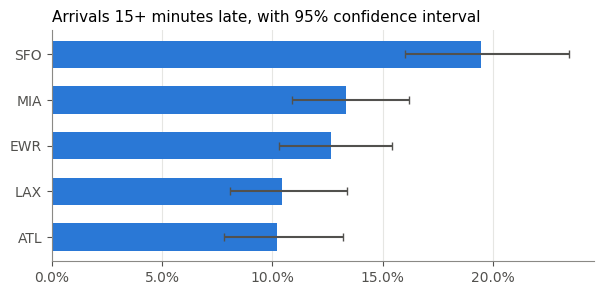

In [8]:
error_below = by_airport["late_rate"] - by_airport["ci_low"]
error_above = by_airport["ci_high"] - by_airport["late_rate"]

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(
    by_airport.index,
    by_airport["late_rate"],
    xerr=[error_below, error_above],
    color=BAR_COLOR,
    height=0.6,
    error_kw={"ecolor": "#52514e", "capsize": 3},
)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="y", visible=False)
ax.set_title("Arrivals 15+ minutes late, with 95% confidence interval", loc="left")
plt.show()

### 2a. Passenger flights only

Cargo flights look rarely late, and an airport with many of them looks more punctual than its
passenger operation really is. _Corrected 4 October 2026:_ that is mostly a data artifact, not how
cargo operates. For several cargo operators (Avianca Cargo, DHL, FedEx, Atlas and others) the
source's "scheduled" arrival is really the landing time, so they almost never look late whatever
happened. Cargo from operators with real schedules is late about as often as passenger flights.
See `ARRIVAL_SCHEDULE_IS_ACTUAL` in `flights_data.py`.

In [9]:
pd.DataFrame({
    "cargo flights": clean.groupby("arrival_airport")["is_cargo"].sum(),
    "late rate, cargo": clean[clean["is_cargo"]].groupby("arrival_airport")["is_delayed_arrival"].mean(),
    "late rate, passenger": clean[~clean["is_cargo"]].groupby("arrival_airport")["is_delayed_arrival"].mean(),
})

,cargo flights,"late rate, cargo","late rate, passenger"
arrival_airport,,,
ATL,23,0.000,0.107
EWR,37,0.081,0.129
LAX,61,0.131,0.101
MIA,165,0.036,0.167
SFO,3,0.000,0.196


### 2b. Same airline, different airport

If SFO itself causes delays, the *same* airline should be later into SFO than into other
airports. Only airline–airport pairs with at least 30 flights are shown.

In [10]:
BIG_CARRIERS = ["United Airlines", "Alaska Airlines", "Delta Air Lines", "American Airlines"]
big = clean[clean["carrier"].isin(BIG_CARRIERS)]

pair_counts = big.pivot_table(index="carrier", columns="arrival_airport",
                              values="is_delayed_arrival", aggfunc="count")
pair_rates = big.pivot_table(index="carrier", columns="arrival_airport",
                             values="is_delayed_arrival", aggfunc="mean")

pair_rates.where(pair_counts >= 30).round(3)

arrival_airport,ATL,EWR,LAX,MIA,SFO
carrier,,,,,
Alaska Airlines,NaN,NaN,0.154,NaN,0.264
American Airlines,0.239,0.246,0.095,0.220,0.185
Delta Air Lines,0.105,0.152,0.105,0.087,0.149
United Airlines,0.109,0.110,0.079,NaN,0.218


## 3. Weather: is there enough variation, and which columns can we trust?

Only flights matched to a weather reading are used in this section. Wind is in mph,
visibility in metres.

In [11]:
weather = clean[clean["has_weather_match"]].copy()

### 3a. The weather label

OpenWeatherMap's one-word summary (`weather_main`). If one value dominates an airport, the
label can't tell that airport's good hours from its bad ones, and it mostly just identifies
the airport.

In [12]:
pd.crosstab(weather["arrival_airport"], weather["weather_main"])

weather_main,Clear,Clouds,Rain
arrival_airport,,,
ATL,180,246,3
EWR,104,481,9
LAX,337,129,0
MIA,1,155,430
SFO,178,210,0


### 3b. Rain

The description separates light, moderate and heavy rain. The key question is whether rain
happens at more than one airport. If it only happens at MIA, a "rain" input would really be a
second "MIA" input.

In [13]:
RAIN_LEVELS = {"light rain": "light", "moderate rain": "moderate", "heavy intensity rain": "heavy"}
weather["rain_level"] = weather["weather_description"].map(RAIN_LEVELS).fillna("none")

# Catch rain-like descriptions the map doesn't know about (drizzle, thunderstorms...),
# so they aren't silently counted as "none".
unmapped = weather.loc[(weather["weather_main"] != "Clear") & (weather["weather_main"] != "Clouds")
                       & (weather["rain_level"] == "none"), "weather_description"].unique()
if len(unmapped):
    print("Not mapped to a rain level:", list(unmapped))

pd.crosstab(weather["arrival_airport"], weather["rain_level"]).reindex(
    columns=["none", "light", "moderate", "heavy"], fill_value=0
)

rain_level,none,light,moderate,heavy
arrival_airport,,,,
ATL,426,0,3,0
EWR,585,9,0,0
LAX,466,0,0,0
MIA,156,408,18,4
SFO,388,0,0,0


### 3c. Visibility

The API reports visibility in metres and never above 10,000 (10 km), so "10,000" really means
"10 km or better". A column that's nearly always at its cap is more useful as a yes/no flag:
**was visibility poor (under 5 km)?** (A few readings, 4 at MIA, have no visibility value. They
count as "not low" below, which barely changes anything.)

In [14]:
weather["visibility_capped"] = weather["weather_visibility_m"] >= 10_000
weather["low_visibility"] = weather["weather_visibility_m"] < 5_000

weather.groupby("arrival_airport")[["visibility_capped", "low_visibility"]].mean()

,visibility_capped,low_visibility
arrival_airport,,
ATL,0.984,0.000
EWR,0.958,0.010
LAX,0.994,0.004
MIA,0.932,0.048
SFO,0.928,0.062


In [15]:
# Are there enough low-visibility flights, and enough late ones among them, to estimate an effect?
weather.groupby("low_visibility")["is_delayed_arrival"].agg(flights="count", late="sum", late_rate="mean")

,flights,late,late_rate
low_visibility,,,
False,2403,330,0.137
True,60,4,0.067


### 3d. Does the label agree with the measurement?

What did the API *call* the weather during the hours when visibility was actually poor?

In [16]:
(
    weather[weather["low_visibility"]]
    .groupby(["arrival_airport", "weather_description"])
    .size()
    .rename("flights")
    .to_frame()
)

flights
arrival_airport weather_description         
EWR             broken clouds              6
LAX             scattered clouds           2
MIA             broken clouds              1
                light rain                25
                overcast clouds            2
SFO             clear sky                 17
                few clouds                 7

### 3e. Wind gusts

`weather_wind_gust` is blank for most readings. Comparing wind speed *within each airport*
shows when a gust gets reported. (Comparing across airports would mix windy airports with
calm ones.)

In [17]:
weather["gust_reported"] = weather["weather_wind_gust"].notna()

weather.pivot_table(
    index="arrival_airport", columns="gust_reported", values="weather_wind_speed", aggfunc="median"
).rename(columns={False: "median wind mph, no gust", True: "median wind mph, gust reported"})

gust_reported,"median wind mph, no gust","median wind mph, gust reported"
arrival_airport,,
ATL,4.61,4.16
EWR,8.05,14.97
LAX,8.05,5.01
MIA,5.75,5.66
SFO,13.80,20.71


In [18]:
print("Correlation between gust and wind speed (where both exist):",
      round(weather["weather_wind_gust"].corr(weather["weather_wind_speed"]), 2))

Correlation between gust and wind speed (where both exist): 0.88


## 4. When are flights scheduled to arrive?

Each pull asks the API for landed flights at one airport and gets back at most 100, its limit.
In the raw files those 100 cover a median of about 8.5 hours of scheduled arrivals (usually 6 to
11, up to about 18). Pulls run at
09:00 UTC, which is overnight in the US, so the sample is mostly US evening and night flights.
Hours are scheduled local time at the arrival airport.

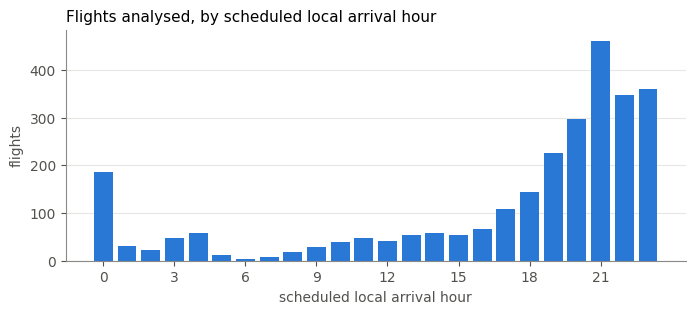

In [19]:
flights_per_hour = clean["arrival_hour"].value_counts().reindex(range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(flights_per_hour.index, flights_per_hour.values, color=BAR_COLOR, width=0.8)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("scheduled local arrival hour")
ax.set_ylabel("flights")
ax.grid(axis="x", visible=False)
ax.set_title("Flights analysed, by scheduled local arrival hour", loc="left")
plt.show()

In [20]:
clean.groupby("time_of_day", observed=True)["is_delayed_arrival"].agg(flights="count", late_rate="mean")

,flights,late_rate
time_of_day,,
night (0-5),356,0.059
morning (6-11),143,0.091
afternoon (12-17),382,0.107
evening (18-23),1832,0.152


### 4a. Does time of day explain SFO?

If SFO simply had more flights in the late-prone evening, its high rate could be a
time-of-day effect rather than an airport effect. The fair comparison is SFO against the
other airports **within the same time slot**. The second table repeats it without the busiest
day, which holds almost all the daytime flights.

In [21]:
def sfo_vs_rest_by_slot(data):
    """Flights and late rate for SFO vs the other four airports, within each time slot."""
    table = data.pivot_table(
        index="time_of_day", columns="is_sfo", values="is_delayed_arrival",
        aggfunc=["count", "mean"], observed=True,
    )
    table.columns = ["flights, other airports", "flights, SFO", "late rate, other airports", "late rate, SFO"]
    return table


sfo_vs_rest_by_slot(clean)

,"flights, other airports","flights, SFO","late rate, other airports","late rate, SFO"
time_of_day,,,,
night (0-5),343,13,0.058,0.077
morning (6-11),94,49,0.064,0.143
afternoon (12-17),325,57,0.086,0.228
evening (18-23),1514,318,0.142,0.201


In [22]:
sfo_vs_rest_by_slot(clean[~on_busiest_day])

,"flights, other airports","flights, SFO","late rate, other airports","late rate, SFO"
time_of_day,,,,
night (0-5),314.0,11.0,0.057,0.091
morning (6-11),1.0,NaN,0.000,NaN
afternoon (12-17),67.0,11.0,0.090,0.364
evening (18-23),1279.0,275.0,0.141,0.189


### 4b. SFO vs each airport, evening flights on regular days

This is the cleanest like-for-like comparison: same time slot, same collection schedule. The
p-value is the chance of seeing a gap this large if the two airports were really the same
(a two-proportion test; it treats flights as independent, so it's a little optimistic).

In [23]:
regular_evenings = clean[~on_busiest_day & (clean["time_of_day"] == "evening (18-23)")]
sfo_evening = regular_evenings[regular_evenings["is_sfo"]]["is_delayed_arrival"]

rows = []
for airport in ["ATL", "EWR", "LAX", "MIA"]:
    other = regular_evenings[regular_evenings["arrival_airport"] == airport]["is_delayed_arrival"]
    _, p_value = proportions_ztest([sfo_evening.sum(), other.sum()], [len(sfo_evening), len(other)])
    rows.append({"airport": airport, "flights": len(other), "late rate": other.mean(),
                 "SFO late rate": sfo_evening.mean(), "p-value": p_value})

pd.DataFrame(rows).set_index("airport")

,flights,late rate,SFO late rate,p-value
airport,,,,
ATL,293,0.119,0.189,0.021
EWR,386,0.130,0.189,0.037
LAX,298,0.138,0.189,0.095
MIA,302,0.179,0.189,0.750


## 5. Carriers: who has enough flights?

A carrier needs enough flights to estimate its own effect. Here the cut-off is 100 flights;
carriers below it will be grouped as "Other" in the regression. Livery names are already
merged (see `flights_data.py`).

In [24]:
flights_per_carrier = clean["carrier"].value_counts()

print(f"{(flights_per_carrier >= 100).sum()} of {len(flights_per_carrier)} carriers have 100+ flights")
flights_per_carrier.head(10)

5 of 106 carriers have 100+ flights


carrier
United Airlines      719
Delta Air Lines      554
American Airlines    440
Alaska Airlines      124
Frontier             103
Air Canada            81
Jetblue               54
Dhl Air               46
Avianca               38
Fedex                 38
Name: count, dtype: int64

In [25]:
# Carriers concentrate at hubs, so a carrier can partly stand in for an airport.
top_carriers = flights_per_carrier[flights_per_carrier >= 100].index
pd.crosstab(clean["carrier"], clean["arrival_airport"], normalize="index").loc[top_carriers].round(2)

arrival_airport,ATL,EWR,LAX,MIA,SFO
carrier,,,,,
United Airlines,0.09,0.55,0.14,0.03,0.18
Delta Air Lines,0.48,0.12,0.16,0.12,0.12
American Airlines,0.10,0.13,0.17,0.48,0.12
Alaska Airlines,0.09,0.02,0.31,0.00,0.58
Frontier,0.18,0.05,0.45,0.27,0.05


## 6. Which flights drop out when we require weather?

Flights without a weather match can't be used in a model with weather inputs. Weather
collection started on the evening of 4 September (UTC), so the flights that landed before
then have no reading to match.

In [26]:
pd.crosstab(clean["has_weather_match"], on_busiest_day.rename("on busiest day"))

on busiest day,False,True
has_weather_match,,
False,0,250
True,1958,505


In [27]:
clean.groupby("has_weather_match")["is_delayed_arrival"].agg(flights="count", late_rate="mean")

,flights,late_rate
has_weather_match,,
False,250,0.080
True,2463,0.136


## 7. Limits of the delay measurement

Two things about the delay numbers themselves that shape what "late" can mean here.

In [28]:
pd.Series({
    "largest arrival delay (min)": clean["arrival_delay_minutes"].max(),
    "flights departing 60+ min late": (clean["departure_delay_minutes"] >= 60).sum(),
    "median departure delay (min)": clean["departure_delay_minutes"].median(),
    "median arrival delay (min)": clean["arrival_delay_minutes"].median(),
})

largest arrival delay (min)        56.0
flights departing 60+ min late    268.0
median departure delay (min)       22.0
median arrival delay (min)        -12.0
dtype: float64

## 8. What this means for the regression

_Snapshot from 2 October 2026 (2,714 flights). The tables above update on re-run; this text does not.
Corrections made on 4 October 2026 are marked._

### The headline, stated carefully

**Across all the data, SFO is late more often than ATL, LAX and EWR.** Its 95% interval
(16.0%–23.4%) doesn't overlap any of theirs, and the overall gap survives dropping the busiest day.
The stricter like-for-like comparison further down narrows this.

**SFO vs MIA is not settled.** MIA's overall rate (13.3%) is pulled down by 165 cargo flights that
are rarely late. On passenger flights only, MIA is 16.7% vs SFO's 19.6%, too close to call with
this much data. _Corrected 4 October 2026:_ cargo looks rarely late mostly because, for several
cargo and charter operators, the source's "scheduled" arrival is really the landing time (see
section 2a). Leaving those operators out as well, MIA's passenger rate is 17.8% vs SFO's 20.0%.

**Same airline, worse at SFO? Mostly.** This is the strongest evidence that the gap isn't just
airline mix. _Corrected 4 October 2026:_ it controls for the carrier, but not for how lateness is
measured at each airport. Arrival times are runway (wheels-on) times and schedules are gate times,
so each airport's typical taxi-in is built into every airline's delays there. This supports the
regression; it doesn't confirm the airport effect independently.
- **United:** 21.8% into SFO vs 11.0% into EWR and 7.9% into LAX.
- **Alaska:** 26.4% into SFO vs 15.4% into LAX.
- **Delta:** 14.9% into SFO vs 10.5% at ATL and LAX and 8.7% at MIA. Only EWR (15.2%) is similar.
- **American is the exception:** 18.5% into SFO, but 22–25% at ATL, EWR and MIA.

### The busiest day is a different kind of day

4 September (28% of all flights) was the first collection day, with 7 manual pulls spread through
the day. After that there was one pull every other day at 09:00 UTC (none on 27 and 29 September,
which the API quota guard skipped), which captures US evening and night flights.
As a result, 4 September contains:
- almost all daytime flights: 143 of the 144 morning flights and 304 of the 382 afternoon flights
- all 251 flights without a weather match, because weather collection started that evening

So "SFO is later in the morning and afternoon" rests mostly on that one day. On the regular days,
SFO's gap is an **evening finding**: 18.9% vs 14.1% on 275 SFO flights. Airport by airport (section 4b),
SFO's evenings are clearly worse than **ATL** (p=0.02) and **EWR** (p=0.04), borderline against
**LAX** (p≈0.10), and no different from **MIA** (p=0.75).

**So the defensible headline is:** *SFO is late more often than ATL and EWR, probably more than LAX,
and not distinguishable from MIA's passenger flights.* That's narrower than "SFO is the least
reliable airport", but it holds up.

### Recommended model setup

- **Main model: 5 September onward.** 1,958 flights, all with a weather match, on a consistent
  collection schedule.
- **Robustness check:** re-fit including 4 September, and compare the SFO effect.
- **Time of day:** with 4 September out, there is essentially no morning (1 flight). Use night vs
  evening, with afternoon (78 flights) merged into evening.
- **Size:** 261 late arrivals. At about 10 late flights per input, that supports roughly 25 inputs.
  The plan uses about 12: airport 4, time of day 1, carrier 5 (livery names merged), cargo 1,
  wind speed 1. The cargo input mostly reflects MIA and LAX, since SFO has almost no cargo flights.
- **Grouping:** flights from the same pull share conditions, so they aren't independent. Group
  them **by pull**, not by date: there are only about 12 pulls, which is too few for ordinary
  clustered standard errors. Use a pull indicator in the model or a wild cluster bootstrap. We'll
  go through what that means in step 2.

### Weather: which columns to use

| Column | Verdict | Why |
|---|---|---|
| `weather_main` (the label) | Don't use | MIA is "Rain" for 73% of flights; SFO and LAX never. It mostly identifies the airport |
| rain | Don't use as a model input | Only 12 rain flights outside MIA, so "rain" would be a second MIA input |
| visibility under 5 km | Report it, don't model it | 60 flights, only 4 of them late. Too few to estimate an effect |
| wind gust | Don't use | At the windy airports (EWR, SFO), gusts come with much stronger wind. Gust tracks wind speed closely (0.88), so wind speed already carries it |
| wind speed (mph) | Use | Present on every weather-matched flight |

The API's label disagrees with its own measurement: of SFO's 24 low-visibility flights, 17 were
labeled "clear sky".

### What the model can and can't answer

It tests whether **SFO's gap survives time of day, carrier and flight type**. It can't yet separate
weather causes from operational ones, which is the project's core question. Weather barely varied
this month, and wind speed is the only usable input. That needs more varied weather (more months)
and, ideally, weather at the origin airport too.

### Limits of the delay data, to state openly

- **No flight in the data arrived more than 56 minutes late,** even though 269 flights departed 60+
  minutes late. Badly delayed flights appear to be missing. Every missing one is a late flight, so
  **late rates are understated**. If more are missing at one airport than another, the airport
  comparison is biased too. **The cause isn't confirmed yet.** This is the most important open
  question about the data. _Corrected 4 October 2026:_ the 269 is a weaker contrast than it looks,
  because flights make up time in the air: departures 60–89 minutes late recover a median of 43
  minutes, so they typically arrive about 26 minutes late. What's really missing is departures
  more than about 90 minutes late (1% of flights). It isn't the pull timing either: the largest
  arrival delay is 55–56 minutes whether a flight was due 4 or 12 hours before the pull, and there
  is no pile-up at 56, so rows are missing rather than clipped. The leading guess is that the
  source leaves out flights more than about an hour late.
- **Late flights scheduled just before a pull are missed.** A flight still in the air at 09:00 UTC
  isn't returned. Flights scheduled within 2 hours of the pull show 1–5% late, against about 14%
  otherwise. LAX (19% of its flights) and MIA (13%) have the most flights in that window and SFO
  the fewest (4%), so the simple comparisons here **understate LAX's and MIA's late rates** and
  flatter SFO's gap against them. The regression corrects for this by leaving those flights out.
- **Departure delay looks off:** the median is +22 minutes while the median arrival is −12.
  _Corrected 4 October 2026:_ confirmed, both are runway times. In every raw record since
  4 September the source's actual departure equals its wheels-off time and its actual arrival equals
  its wheels-on time, while both schedules are gate times. So departures include taxi-out, and
  arrivals leave out taxi-in. Either way, leave departure delay out of the model. A late departure is one of the
  ways an airport makes flights late (e.g. SFO holding inbound flights at their origin), so controlling
  for it would hide the effect being measured.

### Smaller notes

- Carriers cluster at hubs: 58% of Alaska's flights go to SFO and 55% of United's to EWR. Carrier and
  airport effects partly overlap.
- Cargo is identified by a keyword list on carrier names. It catches the major freight operators here
  but isn't exhaustive. _(4 October 2026: a few small cargo and on-demand operators are missed; see
  `flights_data.py`. Their effect on the SFO comparison is negligible.)_

### Still your call for step 2

**Outcome:** late yes/no (logistic regression) or delay in minutes (linear). The missing severe
delays affect both. Late yes/no mirrors the 15-minute rule airlines and the government use (but
measured at wheels-on rather than at the gate, so it isn't directly comparable to official figures),
which makes it the easier result to explain.
